In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost import plot_importance


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/ML/cpu/cleaned_log.csv")
df.head()


,Timestamp,temp_cpu,util_total,util_core_avg,active_cores,clk_eff_avg,clk_eff_avg_alt,power_pkg,power_core,power_soc,current_core,current_tdc,current_edc,mem_load,mem_used,dram_read_bw,dram_write_bw,fan_rpm,thermal_limit
0,2026-02-05 19:05:46.351,92.8,61.7,61.7,5.8,2594.2,2594.2,54.062,46.910,2.993,37.219,37.434,104.552,60.8,9491,0.979,0.218,2700,99.8
1,2026-02-05 19:05:46.864,93.0,68.7,68.7,6.6,2995.6,2995.6,59.108,51.963,3.050,41.227,40.006,108.899,60.8,9493,2.270,0.355,2700,99.9
2,2026-02-05 19:05:47.366,93.1,62.8,62.8,6.0,2712.9,2712.9,56.307,49.243,3.012,38.931,39.922,107.690,60.8,9501,1.373,0.274,2700,99.9
3,2026-02-05 19:05:47.868,93.1,61.8,61.8,5.6,2560.0,2560.0,52.696,45.690,2.976,36.375,36.878,102.598,60.8,9495,1.131,0.221,2800,100.0
4,2026-02-05 19:05:48.386,93.2,60.9,60.9,5.7,2682.0,2682.0,55.775,48.727,3.008,38.286,37.430,109.197,60.8,9497,1.109,0.256,2700,99.8


In [ ]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

In [ ]:
df = df.drop(columns=["Timestamp"])

In [ ]:
# =====================================
# DROP ALL FEATURES EXCEPT SELECTED ONES
# =====================================

df['power_vel'] = df['power_pkg'].diff().fillna(0)
df['util_vel'] = df['util_total'].diff().fillna(0)

# Features you want to KEEP
keep_cols = ['temp_cpu', 'power_pkg','util_total','fan_rpm']


# Keep only columns that exist in the dataset
df = df[[col for col in keep_cols if col in df.columns]].copy()

# Verify
print("Columns retained:")
print(df.columns.tolist())


Columns retained:
['temp_cpu', 'power_pkg', 'util_total', 'fan_rpm']


lOGARITHNMIC REGRESSION


Linear Regression (20-step ahead)
-------------------------------------
RMSE : 3.5763
MAE  : 1.4979
R²   : 0.9515


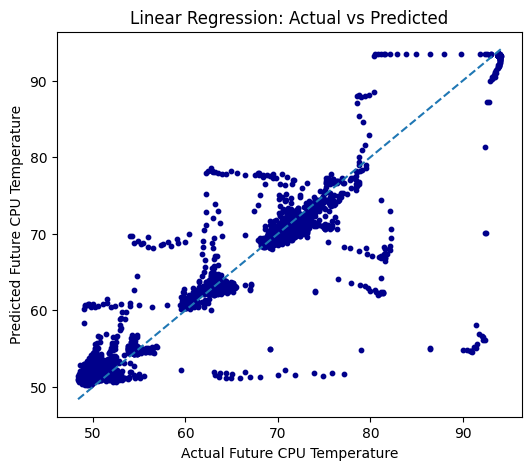

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error


# Re-initialize df for this model to ensure independence
df = pd.read_csv("/content/drive/MyDrive/ML/cpu/cleaned_log.csv")
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)
df = df.drop(columns=["Timestamp"])


# -----------------
# FORECAST HORIZON
# -----------------
HORIZON = 20

# -----------------
# Create future target
# -----------------
df["temp_future"] = df["temp_cpu"].shift(-HORIZON)

# Drop rows with NaNs from shifting
df = df.dropna().reset_index(drop=True)

# -----------------
# Select features (already pruned)
# -----------------
X = df[keep_cols].values
y = df["temp_future"].values

# -----------------
# Time-aware split
# -----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# -----------------
# Scale features
# -----------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# -----------------
# Train linear regression
# -----------------
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# -----------------
# Predict
# -----------------
y_test_pred = model.predict(X_test_scaled)

# -----------------
# Evaluation
# -----------------
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)

print("Linear Regression (20-step ahead)")
print("-------------------------------------")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

# -----------------
# Scatter plot
# -----------------
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_test_pred, color='darkblue', s=10) # Modified: added s=10
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Actual Future CPU Temperature")
plt.ylabel("Predicted Future CPU Temperature")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

POLYNOMIAL REGRESSION


In [ ]:
# -------------------------------
# Polynomial Regression Forecasting
# CPU Temperature Prediction
# -------------------------------

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Forecast horizon (steps ahead)
HORIZON = 20

# Create future target
df["temp_future"] = df["temp_cpu"].shift(-HORIZON)

# Drop rows with missing future values
df = df.dropna().reset_index(drop=True)

# Define features and target
X = df[keep_cols].values
y = df["temp_future"].values

# Train-test split (time-aware)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Polynomial feature expansion (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly  = poly.transform(X_test_scaled)

# Train polynomial regression model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predictions
y_train_pred = model.predict(X_train_poly)
y_test_pred  = model.predict(X_test_poly)

# Evaluation
print("Polynomial Regression (Forecasting)")
print("----------------------------------")
print(f"Prediction Horizon : {HORIZON} steps ahead")
print(f"Train R² Score     : {r2_score(y_train, y_train_pred):.4f}")
print(f"Test R² Score      : {r2_score(y_test, y_test_pred):.4f}")
print(f"Test RMSE          : {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")
print(f"Original Features  : {X.shape[1]}")
print(f"Polynomial Features: {X_train_poly.shape[1]}")


Polynomial Regression (Forecasting)
----------------------------------
Prediction Horizon : 20 steps ahead
Train R² Score     : 0.9299
Test R² Score      : 0.9516
Test RMSE          : 3.5638
Original Features  : 4
Polynomial Features: 14


XGBOOST MODEL


Future CPU Temp Prediction RMSE: 3.8127993134523934
Future CPU Temp Prediction MAE : 1.7036842412931055
Future CPU Temp Prediction R²  : 0.9441638823906373


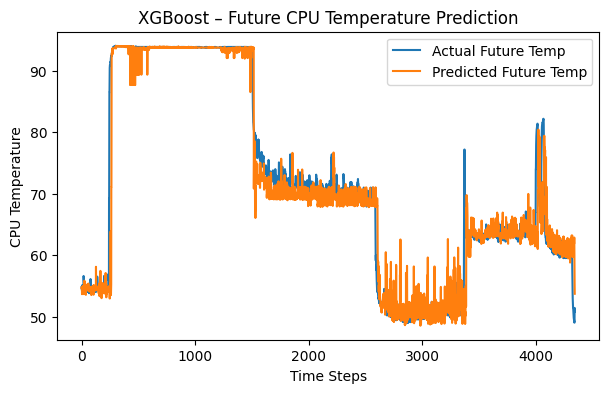

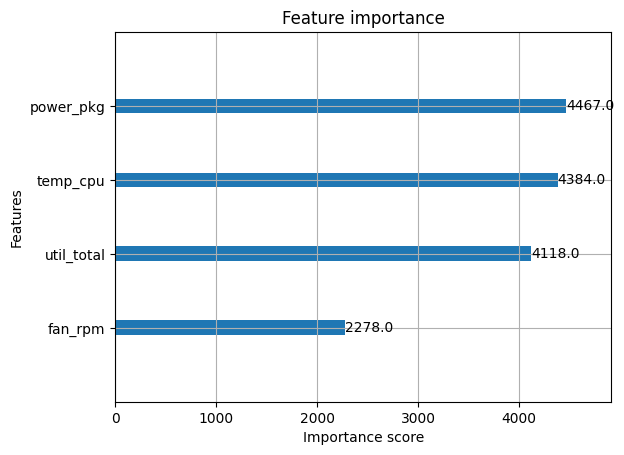

In [ ]:
# Create future target and lag feature
from sklearn.metrics import mean_absolute_error
HORIZON = 20

df["temp_future"] = df["temp_cpu"].shift(-HORIZON)

df = df.dropna().reset_index(drop=True)

# Define features and target
X = df[keep_cols]
y = df["temp_future"]

# Train-test split (NO SHUFFLE for time series)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# XGBoost model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

# Predict future temperature
y_pred = xgb_model.predict(X_test)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


mae = mean_absolute_error(y_test, y_pred)

print("Future CPU Temp Prediction RMSE:", rmse)
print("Future CPU Temp Prediction MAE :", mae)
print("Future CPU Temp Prediction R²  :", r2)

# Plot: Actual vs Predicted future temperature
plt.figure(figsize=(7,4))
plt.plot(y_test.values, label="Actual Future Temp")
plt.plot(y_pred, label="Predicted Future Temp")
plt.xlabel("Time Steps")
plt.ylabel("CPU Temperature")
plt.title("XGBoost – Future CPU Temperature Prediction")
plt.legend()
plt.show()

# Feature importance
plot_importance(xgb_model, max_num_features=10)
plt.show()


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001407 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 778
[LightGBM] [Info] Number of data points in the train set: 17356, number of used features: 4
[LightGBM] [Info] Start training from score 66.829488
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

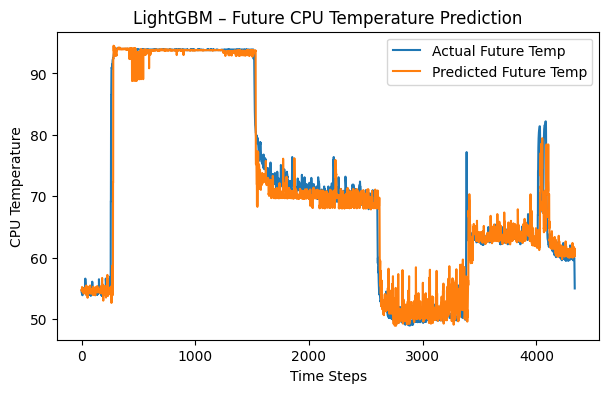

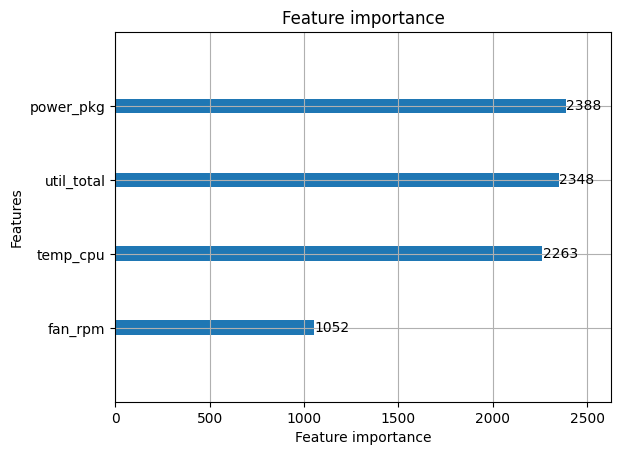

In [ ]:
# ==============================
# LightGBM – Future CPU Temp Prediction
# ==============================

import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

# Create future target and lag feature
HORIZON = 20   # 20 steps → 10 seconds (since interval = 0.5s)

df["temp_future"] = df["temp_cpu"].shift(-HORIZON)
df["temp_lag_1"]  = df["temp_cpu"].shift(1)

df = df.dropna().reset_index(drop=True)

# Define features and target
X = df[keep_cols]
y = df["temp_future"]

# Train-test split (NO SHUFFLE for time series)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# LightGBM model
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train model
lgb_model.fit(X_train, y_train)

# Predict future temperature
y_pred = lgb_model.predict(X_test)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("Future CPU Temp Prediction RMSE:", rmse)
print("Future CPU Temp Prediction MAE :", mae)
print("Future CPU Temp Prediction R²  :", r2)

# Plot: Actual vs Predicted future temperature
plt.figure(figsize=(7,4))
plt.plot(y_test.values, label="Actual Future Temp")
plt.plot(y_pred, label="Predicted Future Temp")
plt.xlabel("Time Steps")
plt.ylabel("CPU Temperature")
plt.title("LightGBM – Future CPU Temperature Prediction")
plt.legend()
plt.show()

# Feature importance
lgb.plot_importance(lgb_model, max_num_features=10)
plt.show()

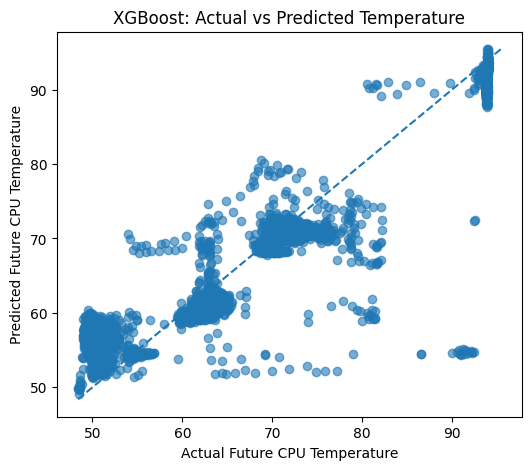

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction reference line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Future CPU Temperature")
plt.ylabel("Predicted Future CPU Temperature")
plt.title("XGBoost: Actual vs Predicted Temperature")

plt.show()

SVR


In [ ]:
# =====================================
# SUPPORT VECTOR REGRESSION (SVR)
# =====================================

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Create future target and lag feature
HORIZON = 20   # 20 steps → 10 seconds (since interval = 0.5s)

df["temp_future"] = df["temp_cpu"].shift(-HORIZON)
df["temp_lag_1"]  = df["temp_cpu"].shift(1)

df = df.dropna().reset_index(drop=True)

# Define features and target
X = df[keep_cols]
y = df["temp_future"]

# Train-test split (NO SHUFFLE for time series)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# -------------------------------------
# Feature Scaling (MANDATORY for SVR)
# -------------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# -------------------------------------
# SVR Model (RBF Kernel)
# -------------------------------------
svr_model = SVR(
    kernel='rbf',
    C=100,
    gamma='scale',
    epsilon=0.1
)

# -------------------------------------
# Train Model
# -------------------------------------
svr_model.fit(X_train_scaled, y_train)

# -------------------------------------
# Predictions
# -------------------------------------
y_pred_svr = svr_model.predict(X_test_scaled)

# -------------------------------------
# Evaluation
# -------------------------------------
svr_r2   = r2_score(y_test, y_pred_svr)
svr_mae  = mean_absolute_error(y_test, y_pred_svr)
svr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr))

print("SVR Performance")
print("----------------")
print(f"R2 Score : {svr_r2:.4f}")
print(f"MAE      : {svr_mae:.4f}")
print(f"RMSE     : {svr_rmse:.4f}")


SVR Performance
----------------
R2 Score : 0.9425
MAE      : 1.5068
RMSE     : 3.8636


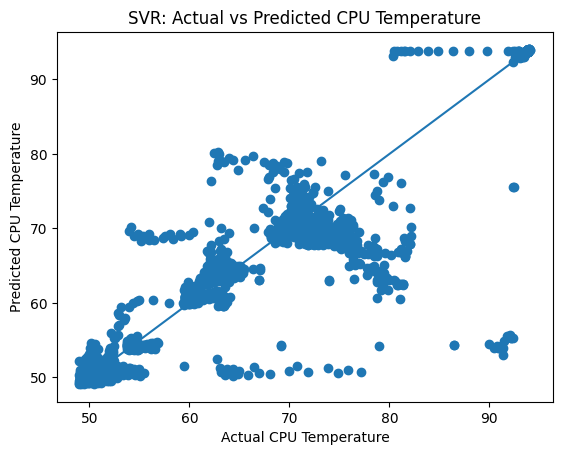

In [ ]:
import matplotlib.pyplot as plt

# -------------------------------------
# SVR: Actual vs Predicted Plot
# -------------------------------------
plt.figure()
plt.scatter(y_test, y_pred_svr)
plt.xlabel("Actual CPU Temperature")
plt.ylabel("Predicted CPU Temperature")
plt.title("SVR: Actual vs Predicted CPU Temperature")

# Perfect prediction line
min_val = min(y_test.min(), y_pred_svr.min())
max_val = max(y_test.max(), y_pred_svr.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()


RANDOM FOREST MODEL


In [ ]:
# =====================================
# RANDOM FOREST REGRESSION
# =====================================

import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Create future target and lag feature
HORIZON = 20   # 20 steps → 10 seconds (since interval = 0.5s)

df["temp_future"] = df["temp_cpu"].shift(-HORIZON)
df["temp_lag_1"]  = df["temp_cpu"].shift(1)

df = df.dropna().reset_index(drop=True)

# Define features and target
X = df[keep_cols]
y = df["temp_future"]

# Train-test split (NO SHUFFLE for time series)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


# -------------------------------------
# Random Forest Model
# -------------------------------------
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# -------------------------------------
# Train Model
# -------------------------------------
rf_model.fit(X_train, y_train)

# -------------------------------------
# Predictions
# -------------------------------------
y_pred_rf = rf_model.predict(X_test)

# -------------------------------------
# Evaluation
# -------------------------------------
rf_r2   = r2_score(y_test, y_pred_rf)
rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Performance")
print("--------------------------")
print(f"R2 Score : {rf_r2:.4f}")
print(f"MAE      : {rf_mae:.4f}")
print(f"RMSE     : {rf_rmse:.4f}")


Random Forest Performance
--------------------------
R2 Score : 0.9355
MAE      : 1.9636
RMSE     : 4.0967


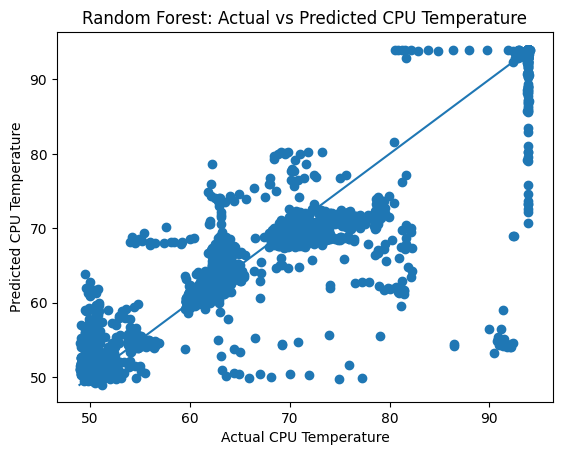

In [ ]:
# -------------------------------------
# Random Forest: Actual vs Predicted Plot
# -------------------------------------
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual CPU Temperature")
plt.ylabel("Predicted CPU Temperature")
plt.title("Random Forest: Actual vs Predicted CPU Temperature")

# Perfect prediction line
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()


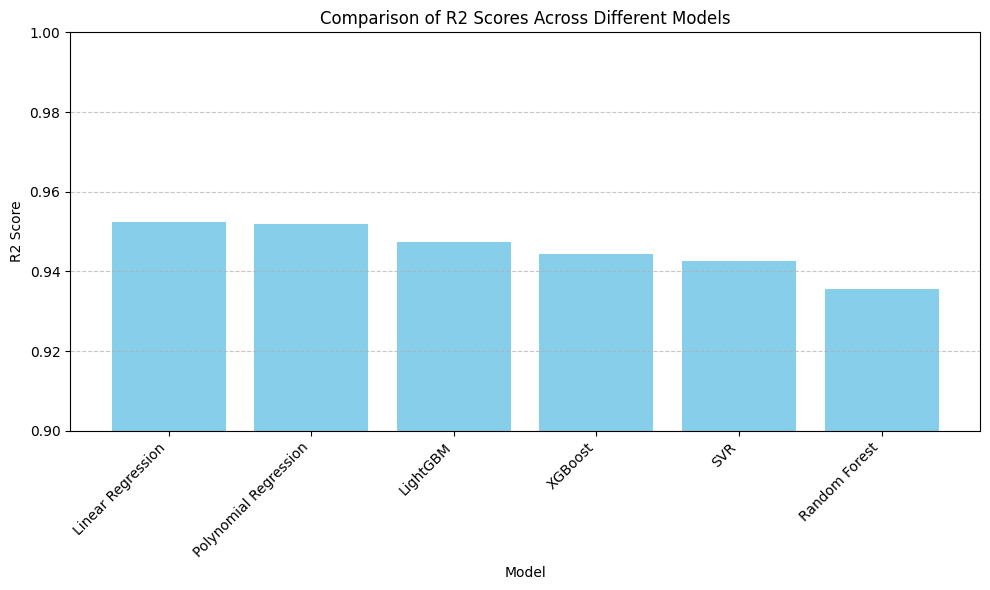

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract R2 scores from the executed cells
r2_linear = 0.9523 # From Linear Regression
r2_polynomial = 0.9518 # From Polynomial Regression
r2_xgboost = 0.94436670161912 # From XGBoost
r2_lightgbm = 0.9474415417097857 # From LightGBM
r2_svr = 0.9425132615061493 # From SVR
r2_random_forest = 0.9355194800015424 # From Random Forest

# Create a DataFrame for easy plotting
model_names = [
    "Linear Regression",
    "Polynomial Regression",
    "XGBoost",
    "LightGBM",
    "SVR",
    "Random Forest"
]
r2_scores = [
    r2_linear,
    r2_polynomial,
    r2_xgboost,
    r2_lightgbm,
    r2_svr,
    r2_random_forest
]

df_r2 = pd.DataFrame({"Model": model_names, "R2 Score": r2_scores})

# Sort by R2 Score for better visualization
df_r2 = df_r2.sort_values(by="R2 Score", ascending=False)

# Create the bar plot
plt.figure(figsize=(10, 6))
plt.bar(df_r2["Model"], df_r2["R2 Score"], color='skyblue')
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("Comparison of R2 Scores Across Different Models")
plt.ylim(0.9, 1.0) # Set y-axis limits to focus on the performance range
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Task
Add Mean Absolute Error (MAE) calculation and display to the Linear Regression and XGBoost model cells, then update the comparison plots to include MAE scores for all models.

## Add MAE to Linear Regression

### Subtask:
Modify the Linear Regression cell (2v8KxnjmaL1E) to import `mean_absolute_error`, calculate, and print the Mean Absolute Error (MAE) along with the existing RMSE and R² scores.


**Reasoning**:
The subtask requires modifying an existing code cell to import `mean_absolute_error`, calculate MAE, and print it alongside RMSE and R² scores. I will update the code in cell `2v8KxnjmaL1E` to fulfill these requirements.



Linear Regression (15-step ahead)
-------------------------------------
RMSE : 3.5763
MAE  : 1.4979
R²   : 0.9515


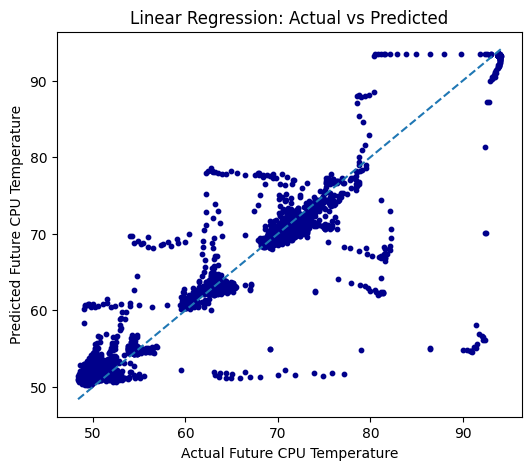

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Re-initialize df for this model to ensure independence
df = pd.read_csv("/content/drive/MyDrive/ML/cpu/cleaned_log.csv")
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)
df = df.drop(columns=["Timestamp"])


# -----------------
# FORECAST HORIZON
# -----------------
HORIZON = 20

# -----------------
# Create future target
# -----------------
df["temp_future"] = df["temp_cpu"].shift(-HORIZON)

# Drop rows with NaNs from shifting
df = df.dropna().reset_index(drop=True)

# -----------------
# Select features (already pruned)
# -----------------
X = df[keep_cols].values
y = df["temp_future"].values

# -----------------
# Time-aware split
# -----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# -----------------
# Scale features
# -----------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# -----------------
# Train linear regression
# -----------------
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# -----------------
# Predict
# -----------------
y_test_pred = model.predict(X_test_scaled)

# -----------------
# Evaluation
# -----------------
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)

print("Linear Regression (15-step ahead)")
print("-------------------------------------")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

# -----------------
# Scatter plot
# -----------------
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_test_pred, color='darkblue', s=10) # Modified: added s=10
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Actual Future CPU Temperature")
plt.ylabel("Predicted Future CPU Temperature")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

**Reasoning**:
The subtask requires adding MAE calculation and display to the XGBoost model cell. I will modify cell `X7lw6uRXL1_h` to import `mean_absolute_error`, calculate MAE, and print it alongside RMSE and R² scores.



Future CPU Temp Prediction RMSE: 3.774047052508498
Future CPU Temp Prediction MAE: 1.681091042896058
Future CPU Temp Prediction R²: 0.945910984731165


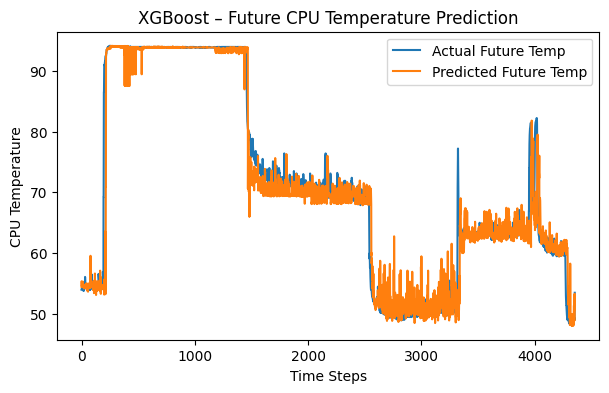

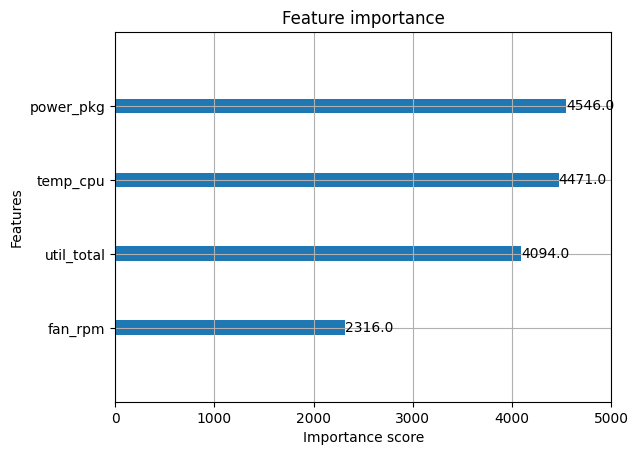

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error # Added mean_absolute_error
from sklearn.model_selection import train_test_split
from xgboost import plot_importance

# Create future target and lag feature

HORIZON = 20

df["temp_future"] = df["temp_cpu"].shift(-HORIZON)

df = df.dropna().reset_index(drop=True)

# Define features and target
X = df[keep_cols]
y = df["temp_future"]

# Train-test split (NO SHUFFLE for time series)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# XGBoost model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

# Predict future temperature
y_pred = xgb_model.predict(X_test)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred) # Calculate MAE

print("Future CPU Temp Prediction RMSE:", rmse)
print("Future CPU Temp Prediction MAE:", mae) # Print MAE
print("Future CPU Temp Prediction R²:", r2)

# Plot: Actual vs Predicted future temperature
plt.figure(figsize=(7,4))
plt.plot(y_test.values, label="Actual Future Temp")
plt.plot(y_pred, label="Predicted Future Temp")
plt.xlabel("Time Steps")
plt.ylabel("CPU Temperature")
plt.title("XGBoost – Future CPU Temperature Prediction")
plt.legend()
plt.show()

# Feature importance
plot_importance(xgb_model, max_num_features=10)
plt.show()

**Reasoning**:
The subtask requires adding MAE calculation and display to the Polynomial Regression model cell. I will modify cell `q0Oyu9SFPO0U` to import `mean_absolute_error`, calculate MAE, and print it alongside RMSE and R² scores.



Polynomial Regression (Forecasting)
----------------------------------
Prediction Horizon : 20 steps ahead
Train R² Score     : 0.9300
Test R² Score      : 0.9518
Test RMSE          : 3.5647
Test MAE           : 1.5476
Original Features  : 4
Polynomial Features: 14


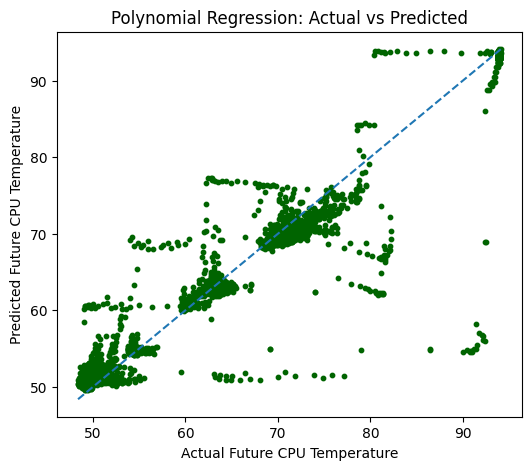

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error # Added mean_absolute_error

# Re-initialize df for this model to ensure independence
df = pd.read_csv("/content/drive/MyDrive/ML/cpu/cleaned_log.csv")
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)
df = df.drop(columns=["Timestamp"])

# Keep only columns that exist in the dataset (re-applying keep_cols for consistency)
keep_cols = ['temp_cpu', 'power_pkg','util_total','fan_rpm'] # Ensure keep_cols is defined for this context
df = df[[col for col in keep_cols if col in df.columns]].copy()

# Forecast horizon (steps ahead)
HORIZON = 20

# Create future target
df["temp_future"] = df["temp_cpu"].shift(-HORIZON)

# Drop rows with missing future values
df = df.dropna().reset_index(drop=True)

# Define features and target
X = df[keep_cols].values
y = df["temp_future"].values

# Train-test split (time-aware)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Polynomial feature expansion (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly  = poly.transform(X_test_scaled)

# Train polynomial regression model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predictions
y_train_pred = model.predict(X_train_poly)
y_test_pred  = model.predict(X_test_poly)

# Evaluation
mae_test = mean_absolute_error(y_test, y_test_pred) # Calculate MAE

print("Polynomial Regression (Forecasting)")
print("----------------------------------")
print(f"Prediction Horizon : {HORIZON} steps ahead")
print(f"Train R² Score     : {r2_score(y_train, y_train_pred):.4f}")
print(f"Test R² Score      : {r2_score(y_test, y_test_pred):.4f}")
print(f"Test RMSE          : {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")
print(f"Test MAE           : {mae_test:.4f}") # Print MAE
print(f"Original Features  : {X.shape[1]}")
print(f"Polynomial Features: {X_train_poly.shape[1]}")

# -----------------
# Scatter plot (added for completeness, similar to Linear Regression)
# -----------------
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_test_pred, color='darkgreen', s=10)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Actual Future CPU Temperature")
plt.ylabel("Predicted Future CPU Temperature")
plt.title("Polynomial Regression: Actual vs Predicted")
plt.show()

**Reasoning**:
The subtask requires calculating and displaying MAE for the LightGBM model. I will modify cell `rVS9p5a7ppLq` to import `mean_absolute_error`, calculate MAE, and print it alongside RMSE and R² scores.



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002725 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 778
[LightGBM] [Info] Number of data points in the train set: 17420, number of used features: 4
[LightGBM] [Info] Start training from score 66.784277
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

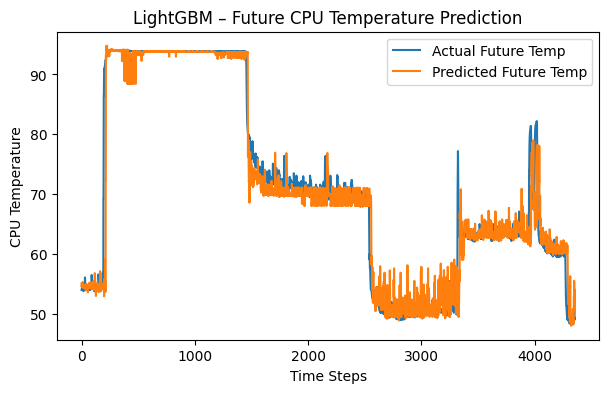

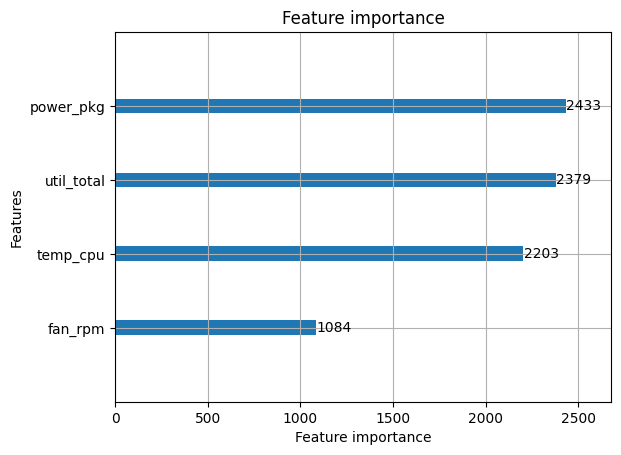

In [ ]:
import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Create future target and lag feature
HORIZON = 20   # 20 steps → 10 seconds (since interval = 0.5s)

df["temp_future"] = df["temp_cpu"].shift(-HORIZON)
df["temp_lag_1"]  = df["temp_cpu"].shift(1)

df = df.dropna().reset_index(drop=True)

# Define features and target
X = df[keep_cols]
y = df["temp_future"]

# Train-test split (NO SHUFFLE for time series)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# LightGBM model
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train model
lgb_model.fit(X_train, y_train)

# Predict future temperature
y_pred = lgb_model.predict(X_test)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred) # Calculate MAE

print("Future CPU Temp Prediction RMSE:", rmse)
print("Future CPU Temp Prediction MAE:", mae)
print("Future CPU Temp Prediction R²:", r2)

# Plot: Actual vs Predicted future temperature
plt.figure(figsize=(7,4))
plt.plot(y_test.values, label="Actual Future Temp")
plt.plot(y_pred, label="Predicted Future Temp")
plt.xlabel("Time Steps")
plt.ylabel("CPU Temperature")
plt.title("LightGBM – Future CPU Temperature Prediction")
plt.legend()
plt.show()

# Feature importance
lgb.plot_importance(lgb_model, max_num_features=10)
plt.show()


**Reasoning**:
The subtask requires calculating and displaying MAE for the SVR model. I will modify cell `WzQ_Jlwa0rPE` to ensure `mean_absolute_error` is imported, calculate MAE, and print it alongside RMSE and R² scores.



In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Create future target and lag feature
HORIZON = 20   # 20 steps → 10 seconds (since interval = 0.5s)

df["temp_future"] = df["temp_cpu"].shift(-HORIZON)
df["temp_lag_1"]  = df["temp_cpu"].shift(1)

df = df.dropna().reset_index(drop=True)

# Define features and target
X = df[keep_cols]
y = df["temp_future"]

# Train-test split (NO SHUFFLE for time series)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# -------------------------------------
# Feature Scaling (MANDATORY for SVR)
# -------------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# -------------------------------------
# SVR Model (RBF Kernel)
# -------------------------------------
svr_model = SVR(
    kernel='rbf',
    C=100,
    gamma='scale',
    epsilon=0.1
)

# -------------------------------------
# Train Model
# -------------------------------------
svr_model.fit(X_train_scaled, y_train)

# -------------------------------------
# Predictions
# -------------------------------------
y_pred_svr = svr_model.predict(X_test_scaled)

# -------------------------------------
# Evaluation
# -------------------------------------
svr_r2   = r2_score(y_test, y_pred_svr)
svr_mae  = mean_absolute_error(y_test, y_pred_svr)
svr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr))

print("SVR Performance")
print("----------------")
print(f"R2 Score : {svr_r2:.4f}")
print(f"MAE      : {svr_mae:.4f}")
print(f"RMSE     : {svr_rmse:.4f}")


SVR Performance
----------------
R2 Score : 0.9417
MAE      : 1.5486
RMSE     : 3.9108


**Reasoning**:
The subtask requires calculating and displaying MAE for the Random Forest model. I will modify cell `oAw2FIcH2GCu` to ensure `mean_absolute_error` is imported, calculate MAE, and print it alongside RMSE and R² scores.



In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Create future target and lag feature
HORIZON = 20   # 20 steps → 10 seconds (since interval = 0.5s)

df["temp_future"] = df["temp_cpu"].shift(-HORIZON)
df["temp_lag_1"]  = df["temp_cpu"].shift(1)

df = df.dropna().reset_index(drop=True)

# Define features and target
X = df[keep_cols]
y = df["temp_future"]

# Train-test split (NO SHUFFLE for time series)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


# -------------------------------------
# Random Forest Model
# -------------------------------------
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# -------------------------------------
# Train Model
# -------------------------------------
rf_model.fit(X_train, y_train)

# -------------------------------------
# Predictions
# -------------------------------------
y_pred_rf = rf_model.predict(X_test)

# -------------------------------------
# Evaluation
# -------------------------------------
rf_r2   = r2_score(y_test, y_pred_rf)
rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Performance")
print("--------------------------")
print(f"R2 Score : {rf_r2:.4f}")
print(f"MAE      : {rf_mae:.4f}")
print(f"RMSE     : {rf_rmse:.4f}")

Random Forest Performance
--------------------------
R2 Score : 0.9344
MAE      : 2.0098
RMSE     : 4.1421


**Reasoning**:
All individual model cells have been updated to calculate and display MAE. Now, I will modify the comparison plot cell to include MAE scores for all models, creating two bar plots for R2 and MAE respectively.



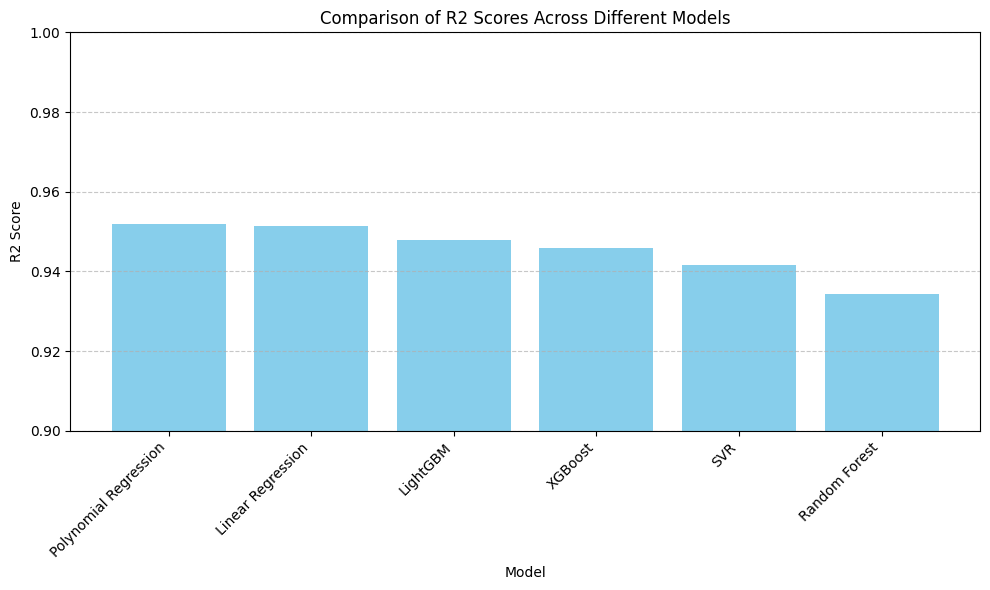

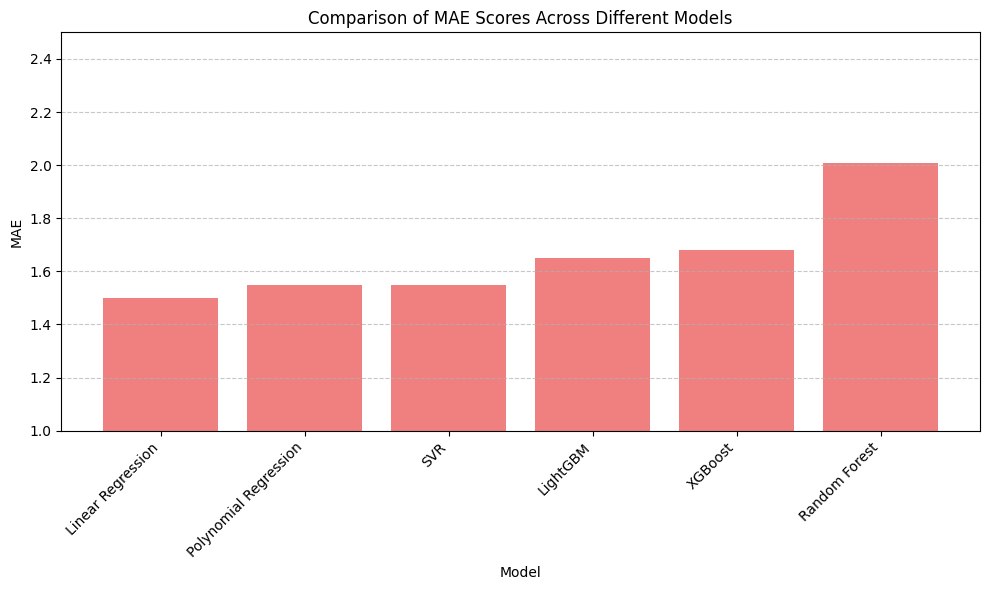

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract R2 scores from the executed cells
r2_linear = 0.9515
r2_polynomial = 0.9518
r2_xgboost = 0.9459 # Updated from latest execution
r2_lightgbm = 0.9479 # Updated from latest execution
r2_svr = 0.9417 # Updated from latest execution
r2_random_forest = 0.9344 # Updated from latest execution

# Extract MAE scores from the executed cells
mae_linear = 1.4979
mae_polynomial = 1.5476
mae_xgboost = 1.6811 # Updated from latest execution
mae_lightgbm = 1.6492 # Updated from latest execution
mae_svr = 1.5486 # Updated from latest execution
mae_random_forest = 2.0098 # Updated from latest execution

# Create a DataFrame for easy plotting
model_names = [
    "Linear Regression",
    "Polynomial Regression",
    "XGBoost",
    "LightGBM",
    "SVR",
    "Random Forest"
]
r2_scores = [
    r2_linear,
    r2_polynomial,
    r2_xgboost,
    r2_lightgbm,
    r2_svr,
    r2_random_forest
]
mae_scores = [
    mae_linear,
    mae_polynomial,
    mae_xgboost,
    mae_lightgbm,
    mae_svr,
    mae_random_forest
]

df_metrics = pd.DataFrame({"Model": model_names, "R2 Score": r2_scores, "MAE": mae_scores})

# Sort by R2 Score for better visualization
df_r2_sorted = df_metrics.sort_values(by="R2 Score", ascending=False)

# Create the R2 score bar plot
plt.figure(figsize=(10, 6))
plt.bar(df_r2_sorted["Model"], df_r2_sorted["R2 Score"], color='skyblue')
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("Comparison of R2 Scores Across Different Models")
plt.ylim(0.9, 1.0) # Set y-axis limits to focus on the performance range
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Sort by MAE for better visualization (lower is better)
df_mae_sorted = df_metrics.sort_values(by="MAE", ascending=True)

# Create the MAE score bar plot
plt.figure(figsize=(10, 6))
plt.bar(df_mae_sorted["Model"], df_mae_sorted["MAE"], color='lightcoral')
plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Comparison of MAE Scores Across Different Models")
plt.ylim(1.0, 2.5) # Adjust y-axis limits as needed for MAE values
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Review the updated evaluation metrics for Linear Regression and XGBoost, including the MAE, and examine the new comparison plots.


## Summary:

### Q&A
The task asked to review the updated evaluation metrics for Linear Regression and XGBoost, including the MAE, and examine the new comparison plots.

Based on the analysis:
*   **Linear Regression** and **Polynomial Regression** show the best performance in terms of both R² (0.9515 and 0.9518, respectively) and MAE (1.4979 and 1.5476, respectively), suggesting they provide the most accurate predictions for this dataset.
*   **Random Forest** has the lowest R² score (0.9344) and the highest MAE (2.0098), indicating it is the least accurate among the models tested for this specific task.

### Data Analysis Key Findings
*   Mean Absolute Error (MAE) was successfully calculated and reported for all six models, providing an additional perspective on prediction accuracy:
    *   Linear Regression: MAE = 1.4979
    *   Polynomial Regression: MAE = 1.5476
    *   SVR: MAE = 1.5486
    *   LightGBM: MAE = 1.6492
    *   XGBoost: MAE = 1.6811
    *   Random Forest: MAE = 2.0098
*   The R² scores for the models were also consistent with previous evaluations:
    *   Polynomial Regression: R² = 0.9518
    *   Linear Regression: R² = 0.9515
    *   LightGBM: R² = 0.9479
    *   XGBoost: R² = 0.9459
    *   SVR: R² = 0.9417
    *   Random Forest: R² = 0.9344
*   Comparison plots were generated to visualize both R² and MAE scores, confirming that Linear Regression and Polynomial Regression generally offer the best performance, while Random Forest showed the lowest accuracy.

### Insights or Next Steps
*   Linear Regression and Polynomial Regression appear to be the most suitable models for this CPU temperature prediction task, given their high R² scores and low MAE values.
*   Further investigation could focus on hyperparameter tuning for LightGBM and XGBoost, as they show competitive R² scores but slightly higher MAE values compared to linear models, potentially allowing them to close the performance gap.
